In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="pastel")  # đẹp hơn mặc định
np.random.seed(42)

n = 1000
df = pd.DataFrame({
    "customer_id": np.random.randint(1, 300, n),
    "order_value": np.random.exponential(100, n),
    "discount": np.random.uniform(0, 0.3, n),
    "device": np.random.choice(["mobile", "desktop"], n, p=[0.7, 0.3]),
    "region": np.random.choice(["A", "B", "C"], n),
    "date": pd.date_range(start="2024-01-01", periods=n, freq="D")
})

df["converted"] = (df["order_value"] > 80).astype(int)
df["month"] = df["date"].dt.to_period("M")

In [4]:
df.head()

,customer_id,order_value,discount,device,region,date,converted,month
0,103,83.204410,0.252600,mobile,B,2024-01-01,1,2024-01
1,271,6.796694,0.218547,mobile,A,2024-01-02,0,2024-01
2,107,149.400259,0.232934,desktop,A,2024-01-03,1,2024-01
3,72,60.383465,0.196849,mobile,A,2024-01-04,0,2024-01
4,189,74.315765,0.053229,desktop,C,2024-01-05,0,2024-01


# 1. 📊 Histogram — phân phối dữ liệu

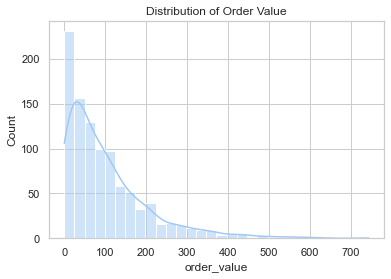

In [7]:
sns.histplot(df["order_value"],bins=30, kde=True)
plt.title("Distribution of Order Value")
plt.show()

Giải thích:
- `data`: dữ liệu đầu vào
- `bins=30`: chia dữ liệu thành 30 khoảng
- `Frequency`: số lượng data trong mỗi khoảng

👉 Dùng khi:

Xem skew / outlier / long tail

👉 Tip:

kde=True để nhìn smooth hơn

👉 Cách đọc Histogram (QUAN TRỌNG)

Một histogram có 3 thứ bạn phải nhìn:
- (1) Shape (Hình dạng phân phối):
    - Normal Distribution (chuẩn)
        - Hình chuông
        - Data tập trung ở giữa

        👉 Insight:

        - Dữ liệu ổn định
        - Có thể dùng nhiều statistical method
    - Skewed (lệch)
        - Lệch phải (Right-skewed)
            - Đuôi kéo dài bên phải

        👉 Ví dụ: Income (thu nhập)

        👉 Insight:
            - Mean > Median
            - Có nhiều giá trị nhỏ, ít giá trị lớn
        - Lệch trái (Left-skewed)
            - Đuôi bên trái
            
- (2) Spread (Độ phân tán)
    
    👉 Nhìn xem:
    - Biểu đồ rộng → data phân tán
    - Hẹp → data tập trung

    👉 Insight:
    - Rộng = variance cao
    - Hẹp = variance thấp
- (3) Outliers (ngoại lệ)

    👉 Nhìn: Các cột đứng riêng lẻ

    👉 Insight:
    - Có thể là lỗi data
    - Hoặc nhóm khách hàng đặc biệt (VIP)
    
👉 Ví dụ phân tích thực tế: Giả sử bạn có histogram của customer spending

    Case 1: Lệch phải

    👉 Insight:
    - 80% khách chi ít
    - 20% khách chi rất nhiều

    👉 Action:
    - Tạo nhóm VIP customers
    - Target marketing riêng
    
    Case 2: 2 đỉnh (Bimodal)
    👉 Insight: Có 2 nhóm khách khác nhau
    👉 Action: Làm segmentation
    
    Case 3: Có outlier
    👉 Insight: Có khách chi cực lớn
    👉 Action: Kiểm tra fraud hoặc VIP
    
👉 Rule: 20–50 bins là đẹp

👉Checklist khi đọc Histogram (giống Data Analyst thật)

Khi nhìn vào histogram, hãy tự hỏi:
- Phân phối có chuẩn không?
- Có bị lệch không?
- Có outlier không?
- Có nhiều đỉnh không?
- Data tập trung ở đâu?

# 2. 📦 Boxplot — phát hiện outlier

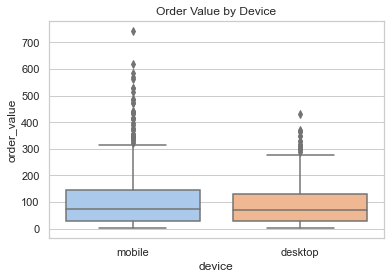

In [5]:
sns.boxplot(x="device", y="order_value", data=df)
plt.title("Order Value by Device")
plt.show()

👉 Boxplot (hay box-and-whisker plot) tóm tắt dữ liệu bằng 5 số quan trọng:
- Min
- Q1 (25%)
- Median (50%)
- Q3 (75%)
- Max

👉 Insight:

Nhìn median + outlier ngay lập tức

👉 Tip:

So sánh giữa các nhóm cực nhanh

👉 Cách đọc Boxplot (CỰC QUAN TRỌNG)

Một boxplot có 4 phần chính:

- (1) Median (đường giữa hộp)
    
    👉 Đây là giá trị trung vị
    
    👉 Insight:
    - Median cao → nhóm này “giá trị cao hơn”
    - So sánh median giữa các nhóm = so sánh nhanh performance
    
- (2) Box (Q1 → Q3)
    
    👉 50% dữ liệu nằm trong box
    
    👉 Insight:
    - Box rộng → data phân tán lớn
    - Box hẹp → data ổn định
- (3) Whiskers (râu)

    👉 Thường kéo đến:
    - Q1 - 1.5 * IQR
    - Q3 + 1.5 * IQR
    - (IQR = Q3 - Q1)

    👉 Insight: Cho biết phạm vi “bình thường”
- (4) Outliers (điểm rời rạc)

👉 Những chấm nằm ngoài whiskers

👉 Insight: Rất quan trọng trong business:
- Fraud? (các điểm dữ liệu nằm ngoài râu biểu đồ, báo hiệu sự bất thường cần được kiểm tra kỹ lưỡng)
- VIP customer?
- Data error?

👉 Công thức quan trọng (phải nhớ)

IQR (Interquartile Range)
- IQR=Q3−Q1

Outlier rule
- Outlier if x<Q1−1.5⋅IQR or x>Q3+1.5⋅IQR

👉 Ví dụ phân tích thực tế
- Case 1: So sánh spending theo gender

    👉 Nếu: Median Female > Male
    
    👉 Insight: Female spend nhiều hơn
    
    👉 Action: Target marketing vào female

- Case 2: Box rất rộng

    👉 Insight: Khách hàng hành vi không ổn định

    👉 Action: Cần segmentation

- Case 3: Nhiều outliers

    👉 Insight: Có nhóm khách đặc biệt

    👉 Action: Tách VIP / kiểm tra fraud
- Case 4: Box lệch (median không nằm giữa)

    👉 Insight: Data bị skew

    👉 Action: Có thể cần log transform

👉 Kết luận:
- Histogram = hiểu sâu
- Boxplot = hiểu nhanh + so sánh

Đừng chỉ nhìn `mean` → hãy nhìn `median`. Vì: Mean dễ bị outlier kéo

👉 Checklist khi đọc Boxplot (chuẩn DA)

Khi nhìn vào boxplot, hỏi:
- Median có cao/thấp không?
- Box rộng hay hẹp?
- Có outlier không?
- Có skew không?
- Nhóm nào tốt hơn?

# 3. 🎻 Violin Plot — distribution + density

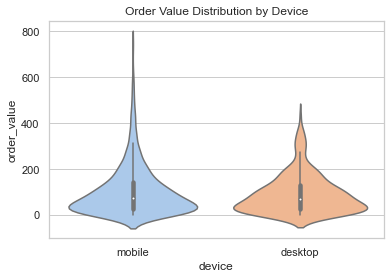

In [9]:
sns.violinplot(x="device", y="order_value", data=df, inner='box')
plt.title("Order Value Distribution by Device")
plt.show()

Violin plot là “phiên bản nâng cấp” của boxplot:
    
    👉 Nó vừa cho bạn summary (như boxplot)
    👉 Vừa cho bạn shape distribution (như histogram/KDE)

`Nếu bạn muốn đọc dữ liệu “như senior DA”, violin plot là cực kỳ đáng học`

Hiểu đơn giản:

    👉 Boxplot + KDE (density distribution)
    - Phần “hộp” → median + IQR
    - Phần “violin” → hình dạng phân phối dữ liệu
👉 Insight:

Shape của distribution (không chỉ median)

👉 Tip:

Dùng khi cần storytelling mạnh hơn boxplot

👉 Đây là cách bạn:
- So sánh nhóm khách hàng
- Phân tích churn / retention
- Phân tích funnel

👉 Cách đọc Violin Plot (ĐIỂM MẠNH NHẤT)
- (1) Width (độ rộng của violin)

    👉 Chỗ nào phình to = nhiều data
    
    👉 Chỗ nào nhỏ = ít data
    
    👉 Insight: Biết data tập trung ở đâu (giống histogram nhưng mượt hơn)
    
- (2) Shape (hình dạng)
    - 1 đỉnh (unimodal): Data tập trung 1 vùng
    - 2 đỉnh (bimodal) 🔥
    
    👉 Insight: Có 2 nhóm khách hàng khác nhau
    
    👉 Action: Segmentation
    
- (3) Median & IQR (nếu có inner box)

    👉 Giống boxplot:
    - So median giữa các nhóm
    - Xem độ phân tán
    
- (4) Tail (đuôi)

    👉 Dài → có outlier / skew
    
    👉 Ngắn → data gọn
    
👉 Ví dụ phân tích thực tế
- Case 1: Hai nhóm có cùng median nhưng shape khác

    👉 Insight:
    - Nhìn boxplot thì tưởng giống nhau
    - Nhưng violin cho thấy:
     - Group A: tập trung
     - Group B: phân tán

    👉 Action: Group B cần optimize
    
- Case 2: Bimodal distribution

    👉 Insight:
    - Có 2 loại user:
     - Low spender
     - High spender

    👉 Action: Split segment
- Case 3: Lệch phải (skewed)

    👉 Insight: Nhiều user chi ít, ít user chi nhiều

    👉 Action: Identify VIP
    
👉 Kết luận:
- Histogram → hiểu sâu
- Boxplot → nhanh & clean
- Violin → cân bằng + insight mạnh nhất khi so nhóm

👉 Không dùng khi data quá ít. `Vì KDE sẽ bị “ảo”`

👉 Checklist đọc Violin (chuẩn DA)

Khi nhìn vào violin plot, hỏi:
- Phân phối có 1 hay nhiều đỉnh?
- Data tập trung ở đâu?
- Nhóm nào có median cao hơn?
- Nhóm nào biến động lớn hơn?
- Có skew không?

👉 Khi nào dùng Violin?
- Dùng khi:
 - So sánh nhiều nhóm
 - Muốn thấy distribution rõ hơn boxplot
 - Làm storytelling nâng cao
- Không nên dùng khi:
 - Data nhỏ
 - Audience không quen (business đôi khi thích boxplot hơn)

# 4. 📊 Barplot — so sánh trung bình

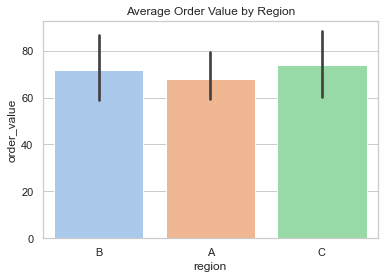

In [15]:
sns.barplot(x="region", y="order_value", data=df, estimator = np.median)
plt.title("Average Order Value by Region")
plt.show()

Nếu histogram = distribution, boxplot/violin = spread → thì barplot = so sánh giá trị giữa các nhóm.

Barplot dùng để:
- So sánh giữa các category (nhóm)
- Thể hiện giá trị tổng hợp (mean, sum, count...)

Ví dụ:
- Doanh thu theo kênh
- Conversion rate theo device
- Số user theo quốc gia

👉 Insight:

Mean + confidence interval

👉 Tip:

Tốt cho slide business

👉 Cách đọc Barplot (RẤT QUAN TRỌNG)
- (1) Chiều cao cột

    👉 Cao hơn = giá trị lớn hơn

    👉 Insight:
    - Kênh nào hiệu quả nhất?
    - Nhóm nào chi tiêu cao nhất?
- (2) So sánh giữa các nhóm

    👉 Đây là mục đích chính

    Ví dụ:
    - Mobile vs Desktop
    - Male vs Female
- (3) Error bar (nếu có)

    👉 Thanh nhỏ trên đầu cột

    👉 Thể hiện: Độ biến động (confidence interval)

    👉 Insight: Error bar lớn → dữ liệu không ổn định

👉 Ví dụ phân tích thực tế
- Case 1: Revenue theo channel

    👉 Facebook > TikTok

    👉 Insight: Facebook hiệu quả hơn

    👉 Action: Tăng budget Facebook
- Case 2: Conversion rate theo device

    👉 Mobile thấp hơn Desktop

    👉 Insight: Mobile UX có vấn đề

    👉 Action: Optimize mobile checkout
- Case 3: Average spending theo segment

    👉 VIP cao nhất

    👉 Insight: VIP là nhóm giá trị

    👉 Action: Loyalty program
    
👉 Checklist đọc Barplot (chuẩn DA)

Khi nhìn vào barplot, hỏi:
- Nhóm nào cao nhất/thấp nhất?
- Sự khác biệt có lớn không?
- Có hợp lý với business không?
- Có bị ảnh hưởng bởi outlier không?

Khi nào dùng Barplot?

    👉 Dùng khi:
    - So sánh giữa các nhóm
    - Báo cáo business
    - Dashboard

👉 Không nên dùng khi: Muốn xem distribution → dùng histogram/violin

# 5. 🔥 Heatmap — correlation matrix

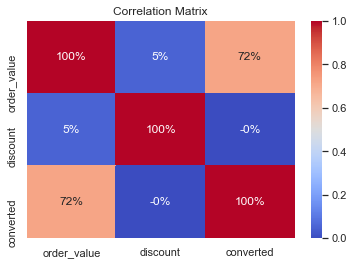

In [10]:
corr = df[["order_value", "discount", "converted"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".0%")
plt.title("Correlation Matrix")
plt.show()

Heatmap là loại biểu đồ “đậm chất Data Analyst” vì nó giúp bạn nhìn ra pattern, tương quan và bất thường chỉ trong 1 cái nhìn.

Heatmap = biểu đồ dùng màu sắc để biểu diễn giá trị
- Màu đậm / sáng = giá trị cao
- Màu nhạt / tối = giá trị thấp

👉 Insight:

Quan hệ giữa variables

👉 Tip:

annot=True để hiện số

👉 Ví dụ:
- Doanh thu theo quốc gia & tháng
- User theo cohort & thời gian

👉 Cách đọc Heatmap (CỰC QUAN TRỌNG)
- (1) Nhìn màu
 - Màu đậm = giá trị cao
 - Màu nhạt = giá trị thấp
 - Insight: Chỗ nào “nóng” → đáng chú ý
- (2) Pattern (mẫu)
 
 👉 Bạn phải tìm:
 - Trend
 - Cluster
 - Shape
- (3) So sánh theo hàng / cột

 👉 Ví dụ:
 - Hàng = country
 - Cột = month
 - Insight: Country nào tốt nhất theo thời gian?
 
👉 Correlation Heatmap – phải hiểu sâu
- Giá trị correlation:
  
  +1 → tương quan dương mạnh
  
  0 → không liên quan
  
  -1 → tương quan âm

Ví dụ:

 👉 Nếu:

 - price ↑ → demand ↓

 👉 Correlation:

 - âm (negative)

Insight:

 👉 Dùng để:
 - Feature selection
 - Hiểu behavior
 - Detect multicollinearity
 
👉 Ví dụ phân tích thực tế
- Case 1: Correlation giữa features

 👉 Nếu:
 - income vs spending = 0.8

 👉 Insight:
 - Thu nhập ảnh hưởng mạnh đến chi tiêu

 👉 Action:
 - Dùng feature này trong model
- Case 2: Cohort retention

 👉 Nếu:
 - retention drop mạnh ở tháng 2

 👉 Insight:
 - User churn sớm

 👉 Action:
 - Improve onboarding
- Case 3: Revenue heatmap

 👉 Nếu:
 - Tháng 12 cực cao

 👉 Insight:
 - Seasonal effect

👉 Action:
 - Tăng marketing cuối năm
 
Sort data trước khi vẽ: Giúp dễ nhìn pattern

Checklist đọc Heatmap (chuẩn DA)

Khi nhìn vào heatmap, hỏi:
- Ô nào nóng nhất?
- Có pattern theo hàng/cột không?
- Có cluster không?
- Có biến nào tương quan mạnh không?
- Có bất thường không?

Khi nào dùng Heatmap?

👉 Dùng khi:
- Phân tích correlation
- Cohort retention
- So sánh matrix data

👉 Không nên dùng khi:
- Data quá ít
- Không có dạng matrix

# 6. 🔵 Scatter Plot — relationship

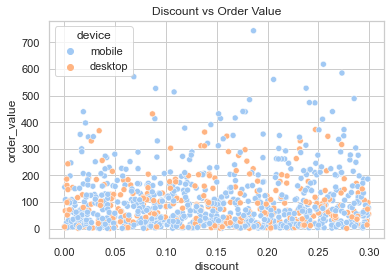

In [11]:
sns.scatterplot(data=df, x="discount", y="order_value", hue="device")
plt.title("Discount vs Order Value")
plt.show()

Scatter plot là biểu đồ bạn dùng khi muốn trả lời câu hỏi cực quan trọng trong phân tích dữ liệu:

👉 “Hai biến này có liên quan gì với nhau không?”

Nó là nền tảng cho:
- Correlation analysis
- Regression
- Detect pattern / outlier

👉 Mỗi điểm = 1 quan sát (data point)

👉 Trục X = biến 1

👉 Trục Y = biến 2

Ví dụ:
- X = income
- Y = spending

👉 Insight:

Linear / cluster

👉 Tip:

hue để phân nhóm

👉 Cách đọc Scatter Plot (CỰC QUAN TRỌNG)
- (1) Direction (hướng)
 - Positive correlation
    - Đi lên ↗
    - X tăng → Y tăng

 - Negative correlation
    - Đi xuống ↘
    - X tăng → Y giảm
 - No correlation
    - Random
    - Không có mối quan hệ rõ

- (2) Strength (độ mạnh)

 👉 Nhìn độ “chặt” của các điểm
 - Chặt → mạnh
 - Rải rác → yếu

- (3) Shape (hình dạng)

👉 Không phải lúc nào cũng là đường thẳng!

Ví dụ:
 - Cong → nonlinear relationship
 - Hình parabol → quadratic

- (4) Outliers

👉 Điểm nằm xa đám đông

👉 Insight:
 - Data error?
 - User đặc biệt?
 
👉Ví dụ phân tích thực tế
- Case 1: Income vs Spending
 - Positive correlation
 - Insight: Người thu nhập cao chi nhiều hơn
 - Action: Target high-income customers
- Case 2: Time on site vs Conversion
 - Nếu không có correlation
 - Insight: Time không phải yếu tố chính
 - Action: Tìm feature khác
- Case 3: Funnel analysis
 - X = bước funnel
 - Y = conversion
 - Insight: Drop ở đâu?
 
👉 Khi nào dùng Scatter Plot?

Dùng khi:
- So sánh 2 biến số
- Tìm correlation
- Detect outlier
- Chuẩn bị cho regression

👉 Không nên dùng khi:
- Data quá nhiều category → dùng barplot
- Muốn xem distribution → dùng histogram

Checklist đọc Scatter (chuẩn DA)

Khi nhìn vào scatter plot, hỏi:
- Có correlation không?
- Positive hay negative?
- Mạnh hay yếu?
- Có pattern gì đặc biệt không?
- Có outlier không?

# 7. 📈 Line Plot — trend theo thời gian

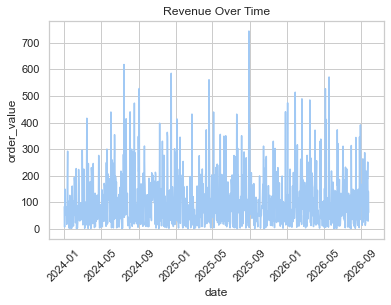

In [12]:
daily = df.groupby("date")["order_value"].sum().reset_index()

sns.lineplot(data=daily, x="date", y="order_value")
plt.title("Revenue Over Time")
plt.xticks(rotation=45)
plt.show()

Line plot (biểu đồ đường) là “vũ khí chính” khi làm time series / trend analysis — gần như 100% dashboard business đều có.

👉 Nó trả lời câu hỏi:
“Metric thay đổi theo thời gian như thế nào?”

- Trục X: thường là thời gian (day, month, year)
- Trục Y: giá trị metric

Ví dụ:
- Revenue theo tháng
- Users theo ngày
- Conversion rate theo tuần

👉 Insight:

Trend / seasonality

👉 Tip:

Luôn rotate trục X nếu dài

👉 Cách đọc Line Plot (CỰC QUAN TRỌNG)
- (1) Trend (xu hướng)
 - Nhìn tổng thể:
    - Đi lên → growth
    - Đi xuống → decline
    - Sideway → ổn định
- (2) Seasonality (tính mùa vụ)
 - Pattern lặp lại:
    - Cuối tuần tăng
    - Tháng 12 tăng mạnh
- (3) Spike / Drop (đột biến)
 - Những điểm bất thường:
    - Tăng đột ngột
    - Giảm mạnh
 - Insight:
    - Campaign?
    - Bug?
    - External event?
- (4) So sánh nhiều line
 - Nhìn:
    - Line nào cao hơn?
    - Line nào tăng nhanh hơn?
    
👉 Ví dụ phân tích thực tế
- Case 1: Revenue tăng dần
 - Insight: Business đang growth
 - Action: Scale marketing
- Case 2: Drop mạnh 1 ngày
 - Insight:
    - Có thể:
    - Website lỗi
    - Payment fail
 - Action: Check system
- Case 3: Seasonality
 - Insight: Cuối tuần tăng
 - Action: Push campaign cuối tuần
- Case 4: So sánh channel
 - Facebook tăng nhanh hơn Google
 - Action: Allocate budget
 
👉 Khi nào dùng Line Plot?

Dùng khi:
 - Time series
 - Trend analysis
 - Growth tracking

Không nên dùng khi:
- So sánh category → dùng barplot
- Distribution → dùng histogram
👉 Checklist đọc Line Plot (chuẩn DA)

Khi nhìn vào line plot, hỏi:
- Trend là gì? (tăng/giảm)
- Có seasonality không?
- Có spike/drop bất thường không?
- Nhóm nào tốt hơn?
- Có điểm nào cần investigate không?

# 8. 🧩 Pairplot — toàn bộ relationship

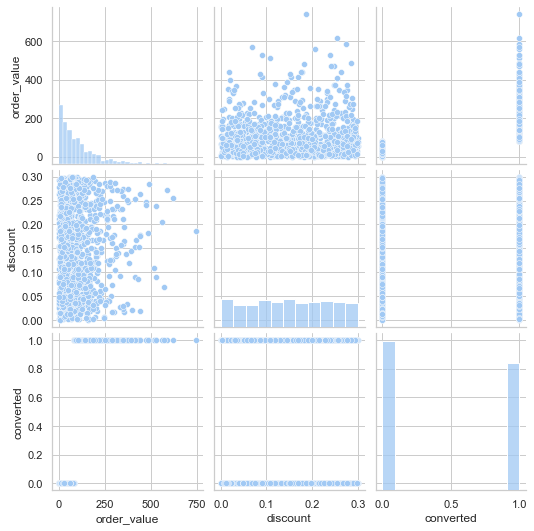

In [13]:
sns.pairplot(df[["order_value", "discount", "converted"]])
plt.show()

Pairplot là một trong những tool “xịn” nhất của EDA vì nó cho bạn nhìn toàn bộ mối quan hệ giữa nhiều biến cùng lúc.
- Nếu scatter plot = 2 biến
- Thì pairplot = tất cả biến vs tất cả biến

Pairplot (trong Seaborn) tạo ra:

Ma trận biểu đồ:
- Đường chéo (diagonal) → distribution (histogram / KDE)
- Ngoài đường chéo → scatter plot giữa từng cặp biến

Thêm hue vào là cách để:
- Nhìn clustering
- Phân biệt nhóm (classification cực mạnh)

Dùng KDE thay vì histogram: `diag_kind="kde"`

👉 Insight:

Overview toàn bộ dataset

👉 Tip:

Rất mạnh cho EDA nhanh

👉 Cách đọc Pairplot (CỰC QUAN TRỌNG)
- (1) Nhìn đường chéo (distribution)
 - Mỗi biến phân phối như thế nào:
    - Chuẩn?
    - Lệch?
    - Có nhiều đỉnh?
- (2) Nhìn scatter giữa các biến
 - Tìm:
    - Correlation
    - Pattern
    - Cluster
- (3) Nhìn màu (hue)
 - Insight cực mạnh:
    - Nhóm có tách biệt không?
    - Có overlap không?

👉 Ví dụ phân tích thực tế
- Case 1: Feature correlation
 - Nếu: X và Y có xu hướng tuyến tính
 - Insight: Có correlation
 - Action: Có thể dùng trong model
- Case 2: Clustering rõ ràng
 - Nếu: Các màu tách biệt
 - Insight: Feature phân loại tốt
 - Action: Dùng cho classification
- Case 3: Overlap nhiều
 - Insight: Khó phân biệt nhóm
 - Action: Cần feature khác
- Case 4: Outliers
 - Dễ thấy điểm nằm xa
 - Action: Clean data
 
👉 Checklist đọc Pairplot (chuẩn DA)

Khi nhìn vào pairplot, hỏi:
- Biến nào có correlation mạnh?
- Có pattern gì không?
- Nhóm có tách biệt không?
- Có outlier không?
- Feature nào quan trọng?

👉 Khi nào dùng Pairplot?

Dùng khi:
- EDA ban đầu
- Khám phá mối quan hệ giữa nhiều biến
- Chuẩn bị cho ML

Không nên dùng khi:
- Dataset quá lớn
- Quá nhiều biến

# 9. 🎯 Countplot — đếm category

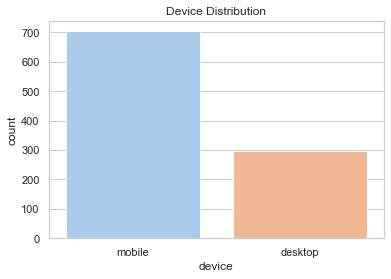

In [14]:
sns.countplot(x="device", data=df)
plt.title("Device Distribution")
plt.show()

Countplot là biểu đồ cực kỳ “cơ bản nhưng không thể thiếu” — bạn sẽ dùng nó liên tục khi làm EDA, đặc biệt với biến dạng category (phân loại).

👉 Nó trả lời câu hỏi đơn giản nhưng quan trọng:
“Có bao nhiêu phần tử trong mỗi nhóm?”

Countplot = đếm số lượng (frequency) của từng category

Ví dụ:
- Bao nhiêu user theo giới tính
- Bao nhiêu đơn hàng theo trạng thái
- Bao nhiêu khách theo segment

👉 Insight:

Data imbalance

👉 Tip:

Dùng khi làm classification

👉 Cách đọc Countplot (CỰC QUAN TRỌNG)
- (1) Chiều cao cột
 - Cao hơn = nhiều hơn
 - Insight: Nhóm nào chiếm đa số?
- (2) So sánh giữa các nhóm
 - Ví dụ:
    - Male vs Female
    - Active vs Churn
- (3) Nhìn imbalance (mất cân bằng)

RẤT QUAN TRỌNG trong ML

 Ví dụ:
 - 95% không churn
 - 5% churn
 Insight: Dataset bị imbalance
 
 Action: Cần xử lý (resampling)
 
👉 Ví dụ phân tích thực tế
- Case 1: User theo country
 - Việt Nam chiếm 70%
 - Insight: Thị trường chính là VN
 - Action: Focus marketing VN
- Case 2: Churn vs Active
 - Churn rất ít
 - Insight:
    - Nhưng có thể:
        - Data imbalance
        - Hoặc business tốt
- Case 3: Segment distribution
 - VIP rất ít
 - Insight: Nhóm giá trị cao nhưng hiếm
 - Action: Tăng retention VIP
 
👉 Khi nào dùng Countplot?

Dùng khi:
- Phân tích category
- Kiểm tra imbalance
- Hiểu distribution của label (ML)
 
Không nên dùng khi: Dữ liệu numeric → dùng histogram

👉 Checklist đọc Countplot (chuẩn DA)

Khi nhìn vào countplot, hỏi:
- Nhóm nào nhiều nhất?
- Có imbalance không?
- Có nhóm nào bất thường không?
- Tỷ lệ có hợp lý không?

Tổng kết nhanh (rất đáng nhớ)
- Countplot = đếm
- Barplot = trung bình / tổng
- Histogram = phân phối số

# 10. 📊 FacetGrid — phân tích đa chiều

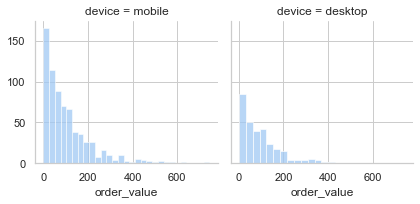

In [15]:
g = sns.FacetGrid(df, col="device")
g.map(sns.histplot, "order_value")
plt.show()

Đây là thứ giúp bạn: chia nhỏ dữ liệu thành nhiều biểu đồ theo từng nhóm → cực mạnh cho storytelling

FacetGrid =
- Tạo nhiều subplot (nhiều biểu đồ nhỏ)
- Mỗi biểu đồ = 1 subset của data

Ví dụ:
- 1 biểu đồ cho mỗi country
- 1 biểu đồ cho mỗi segment
- 1 biểu đồ cho mỗi device

👉 Insight:

So sánh distribution giữa nhóm

👉 Tip:

Rất mạnh cho segmentation

👉Khi nào dùng FacetGrid?

Khi bạn muốn trả lời:
- “Trend này có giống nhau giữa các nhóm không?”
- “Distribution có khác giữa segment không?”
- “User behavior khác nhau theo country không?”

👉 Cách đọc FacetGrid (CỰC QUAN TRỌNG)
- (1) So sánh giữa các subplot
 - Câu hỏi chính:
    - Nhóm nào khác biệt?
    - Trend có giống nhau không?
- (2) Nhìn pattern trong từng subplot
 - Ví dụ:
    - Scatter → correlation khác nhau giữa nhóm
    - Histogram → distribution khác nhau
- (3) Nhìn consistency
 - Insight cực mạnh:
    - Nếu tất cả giống nhau → behavior consistent
    - Nếu khác → cần segmentation
👉 Ví dụ phân tích thực tế
- Case 1: Revenue theo channel & country
 - Nếu:
    - US tăng mạnh
    - VN đi ngang
 - Insight: Performance khác nhau theo thị trường
 - Action: Optimize từng market
- Case 2: Churn theo segment
 - Nếu:
    - Segment A churn cao
    - Segment B thấp
 - Insight: Có vấn đề riêng từng segment
- Case 3: Funnel theo device
 - Mobile vs Desktop khác nhau
 - Insight: UX issue mobile
 
👉 Sai lầm phổ biến

❌ Quá nhiều subplot

 - Sẽ:
    - Rối
    - Không đọc được

 - Rule: max 6–8 plots

❌ Không scale đồng nhất
 - So sánh sai
 - Giải pháp: Dùng cùng trục (Seaborn thường handle tốt)

❌ Không có tiêu đề rõ
 - Không biết đang nhìn cái gì
 
👉 Combine với các plot khác

FacetGrid có thể dùng với:
- histogram
- scatter
- line
- boxplot

👉 Checklist (chuẩn DA)

Khi dùng FacetGrid, hỏi:
- Nhóm nào khác biệt?
- Trend có giống nhau không?
- Có segment nào bất thường không?
- Có cần chia nhỏ analysis không?

Tổng kết dễ nhớ
- Scatter = 2 biến
- Pairplot = nhiều biến
- FacetGrid = nhiều nhóm 🔥

# 🔥 BONUS — Combo đẹp (dashboard-ready)

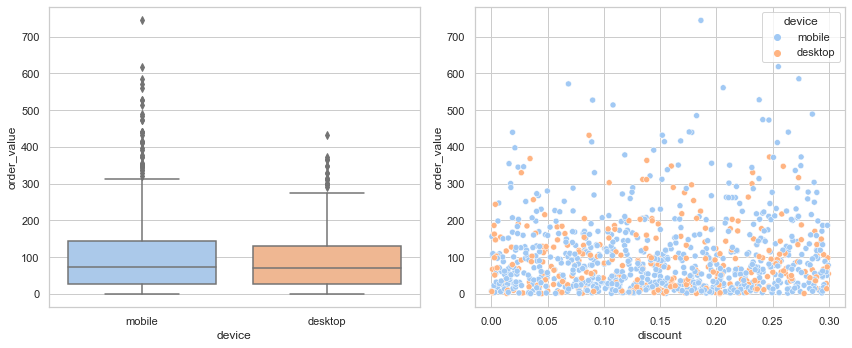

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x="device", y="order_value", data=df)

plt.subplot(1,2,2)
sns.scatterplot(data=df, x="discount", y="order_value", hue="device")

plt.tight_layout()
plt.show()

# 🎯 CÁCH CHỌN BIỂU ĐỒ (quan trọng hơn code)

| Mục tiêu        | Biểu đồ             |
| --------------- | ------------------- |
| Distribution    | Hist / KDE / Violin |
| So sánh         | Bar / Box           |
| Relationship    | Scatter             |
| Time            | Line                |
| Correlation     | Heatmap             |
| Category        | Countplot           |
| Multi-dimension | FacetGrid           |


⚠️ GÓC THẲNG

Sai lầm phổ biến:

- Dùng quá nhiều chart nhưng không có insight
- Chọn sai chart (ví dụ dùng bar cho distribution)
- Không annotate → người xem không hiểu